# Fraud Detection Project

### Insurance Claim Fraud Detection Using Machine Learning

## Data Overview
Understanding dataset structure and variable types

In [1]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

# Imbalanced Learning
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Model Optimization
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

# Advanced Optimization
import optuna

# Evaluation Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
# Load Dataset

df = pd.read_csv("data/data.csv")
pd.set_option('display.max_columns', None)
df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
# Dataset Overview

print(f"Dataset Shape: {df.shape}")

df.describe()

Dataset Shape: (15420, 33)


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [4]:
# Summary Statistics and Feature Overview

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "unique": df.apply(lambda x: x.unique()),
    "mean": df.mean(numeric_only=True),
    "max": df.max(numeric_only=True),
    "min": df.min(numeric_only=True),
    "range": df.max(numeric_only=True) - df.min(numeric_only=True),
    "std": df.std(numeric_only=True),
    "skew": df.skew(numeric_only=True)
})

summary = summary.loc[df.columns]

summary

,dtype,n_unique,unique,mean,max,min,range,std,skew
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",NaN,NaN,NaN,NaN,NaN,NaN
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",2.788586,5.0,1.0,4.0,1.287585,0.115426
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",NaN,NaN,NaN,NaN,NaN,NaN
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",NaN,NaN,NaN,NaN,NaN,NaN
AccidentArea,object,2,"[Urban, Rural]",NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",NaN,NaN,NaN,NaN,NaN,NaN
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",NaN,NaN,NaN,NaN,NaN,NaN
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",2.693969,5.0,1.0,4.0,1.259115,0.158233
Sex,object,2,"[Female, Male]",NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",NaN,NaN,NaN,NaN,NaN,NaN


## Data Quality


In [5]:
# Missing Values and Duplicate Check

df.isna().sum()

df.duplicated().sum()


np.int64(0)

In [6]:
# Data Cleaning

# Fix invalid age values
df.loc[df["Age"] == 0, "Age"] = pd.NA
df["Age"] = df["Age"].fillna(df["Age"].median())

# Drop ID column
df = df.drop(columns=["PolicyNumber"], errors="ignore")

# Fix invalid MonthClaimed values
df.loc[df["MonthClaimed"] == "0", "MonthClaimed"] = pd.NA
df = df.dropna(subset=["MonthClaimed"])

In [7]:
# Data Quality Check After Cleaning

df.isna().sum()

print(f"Dataset Shape After Cleaning: {df.shape}")


Dataset Shape After Cleaning: (15419, 32)


## Target Analysis


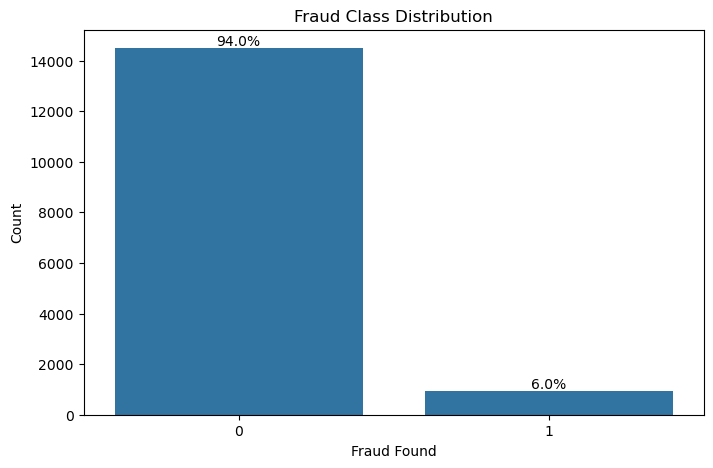

In [8]:
df_eda = df.copy()

plt.figure(figsize=(8,5))

ax= sns.countplot(data=df_eda, x="FraudFound_P")

total=len(df_eda)

for p in ax.patches:
    percentage=100*p.get_height()/total

    ax.annotate(f"{percentage:.1f}%",
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',
                va='bottom')

plt.title("Fraud Class Distribution")
plt.xlabel("Fraud Found")
plt.ylabel("Count")

plt.show()


## Feature vs Target Analysis


### Numerical Features

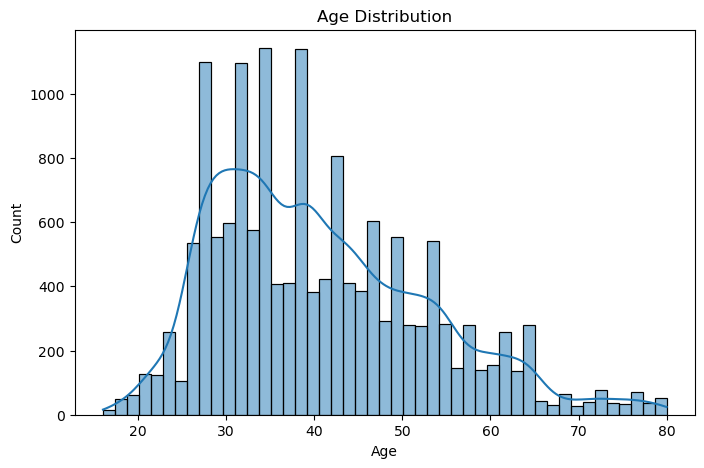

In [9]:
# Numerical Feature Distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df_eda, x="Age", kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

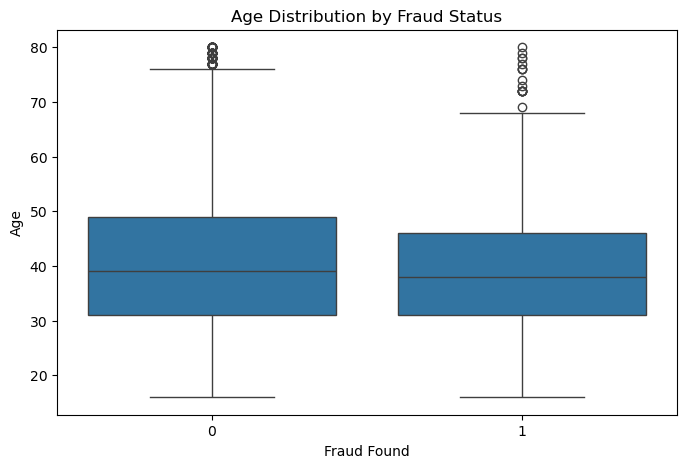

In [10]:
# Age Distribution by Fraud Status

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_eda, x="FraudFound_P", y="Age")

plt.title("Age Distribution by Fraud Status")
plt.xlabel("Fraud Found")
plt.ylabel("Age")

plt.show()

### Correlation Analysis

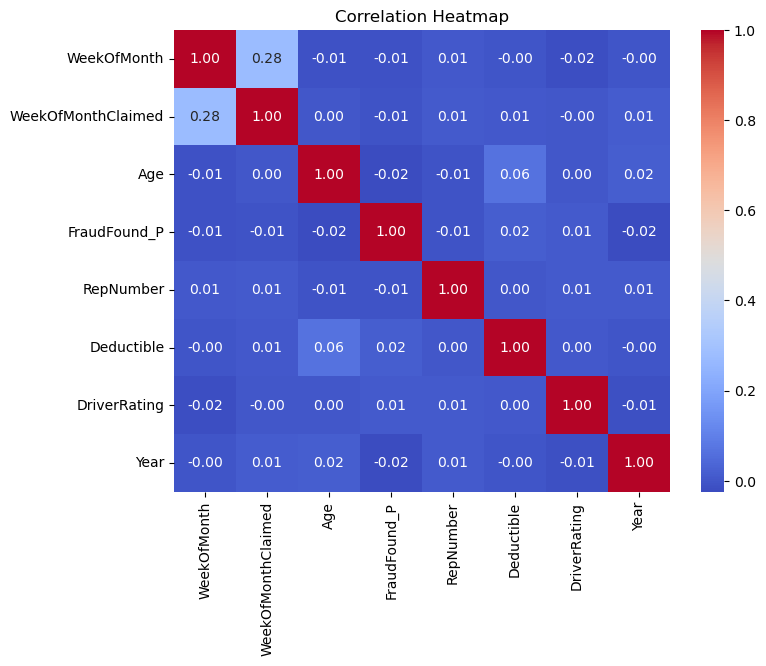

In [11]:
# Correlation Heatmap

num_cols = df_eda.select_dtypes(include=np.number).columns

plt.figure(figsize=(8, 6))

sns.heatmap(df_eda[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Categorical Features

In [12]:
# Fraud Rate Plot Function

overall_rate = df_eda["FraudFound_P"].mean()

def plot_fraud_rate(data, feature, order=None, sort=False):
    
    fraud_rate = data.groupby(feature)["FraudFound_P"].mean()
    
    if order is not None:
        fraud_rate = fraud_rate.reindex(order)
        
    if sort:
        fraud_rate = fraud_rate.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    
    ax = fraud_rate.plot(kind="bar")
    
    ax.axhline(overall_rate,
               color="red",
               linestyle="--",
               label="Overall Fraud Rate")

    plt.title(f"Fraud Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Fraud Rate")
    
    plt.legend()
    
    plt.show()

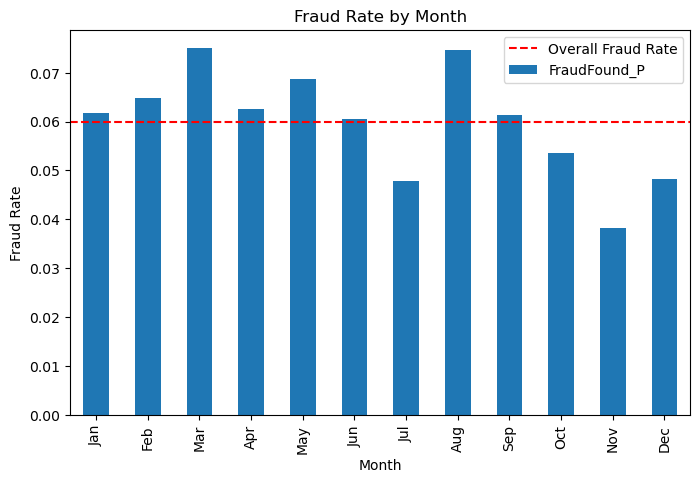

In [13]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]


plot_fraud_rate(df_eda, "Month", order=month_order)

Fraud rates appear to decline toward the end of the year, with notably lower rates observed in November and December compared to earlier months.

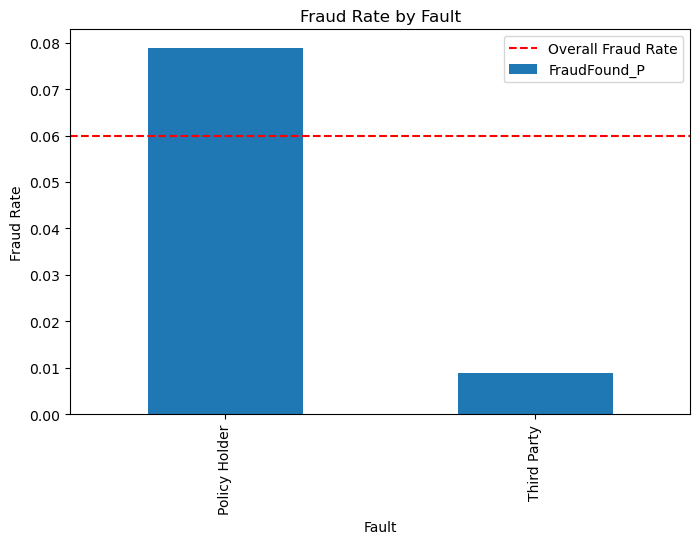

In [14]:
plot_fraud_rate(df_eda, "Fault")

Fraud rates are substantially higher when the policy holder is reported at fault compared to cases involving third parties.

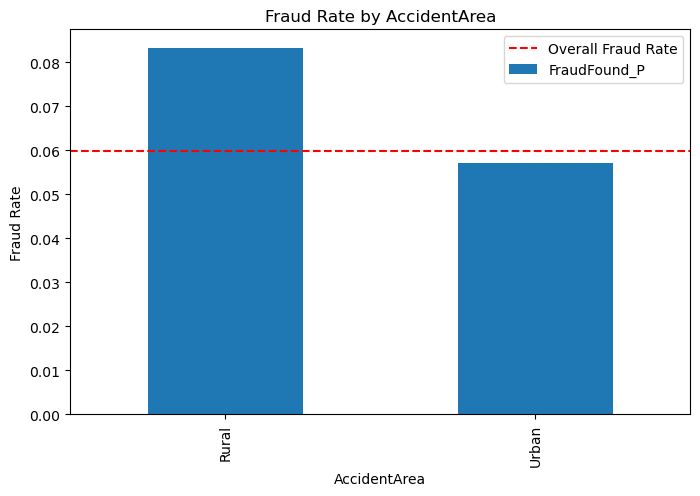

In [15]:
plot_fraud_rate(df_eda, "AccidentArea")

Fraud rates appear higher in rural areas compared to urban areas.

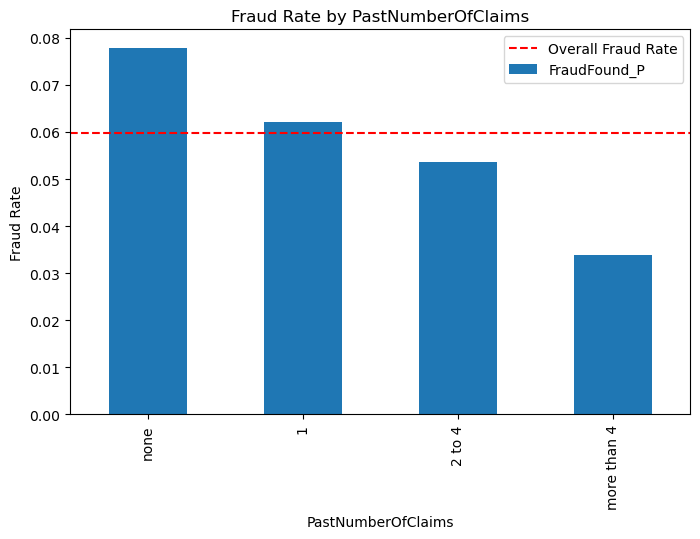

In [16]:
claims_order = ["none", "1", "2 to 4", "more than 4"]

plot_fraud_rate(df_eda, "PastNumberOfClaims",
                order=claims_order)

Fraud rates appear higher among policy holders with no prior claim history, while lower fraud rates are observed for individuals with multiple past claims.

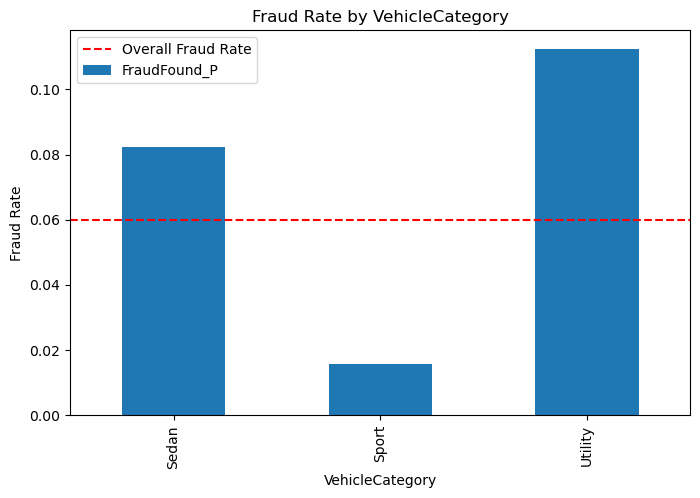

In [17]:
plot_fraud_rate(df_eda, "VehicleCategory")

Utility vehicles show the highest fraud rates among vehicle categories, while sport vehicles exhibit substantially lower fraud rates.

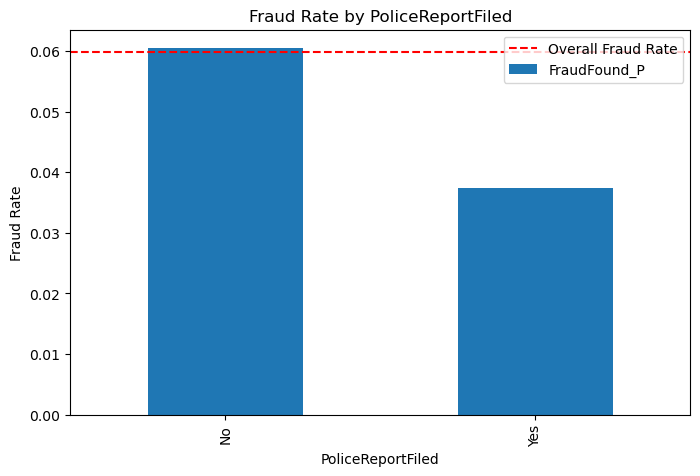

In [18]:
plot_fraud_rate(df_eda, "PoliceReportFiled")

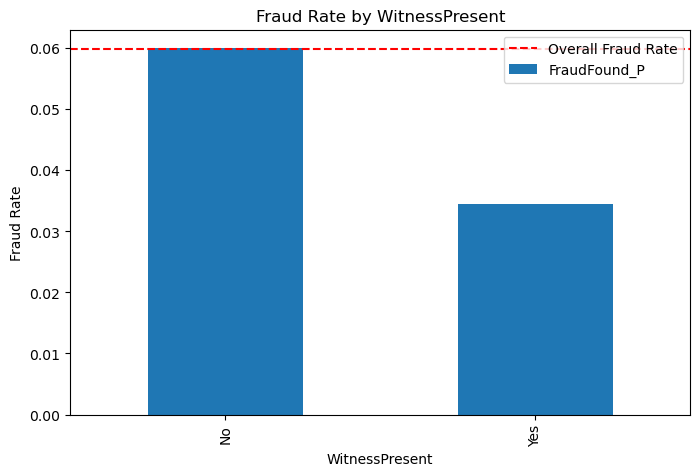

In [19]:
plot_fraud_rate(df_eda, "WitnessPresent")

Fraud rates appear higher for claims without police reports or witnesses, suggesting that reduced external verification may be associated with increased fraud occurrence.

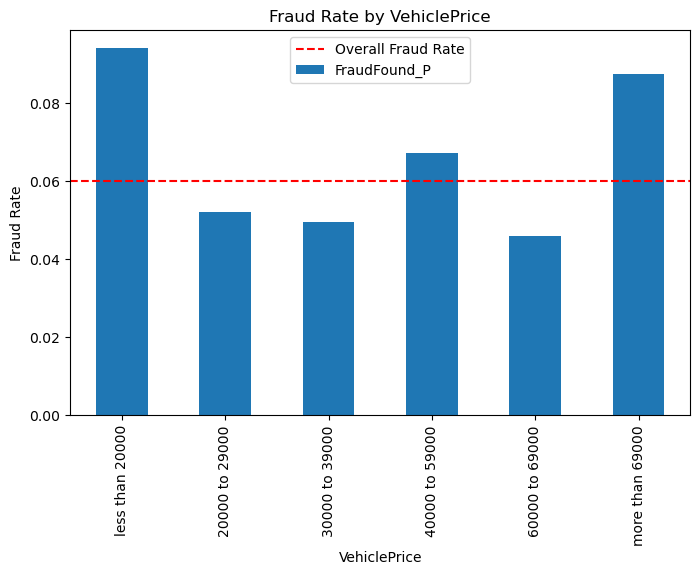

In [20]:
vehicle_price_order = ["less than 20000",
                       "20000 to 29000",
                       "30000 to 39000",
                       "40000 to 59000",
                       "60000 to 69000",
                       "more than 69000"]

plot_fraud_rate(df_eda,
                "VehiclePrice",
                order=vehicle_price_order)

Higher fraud rates are observed for both lower-priced and higher-priced vehicles, while mid-range vehicle categories show comparatively lower fraud rates.

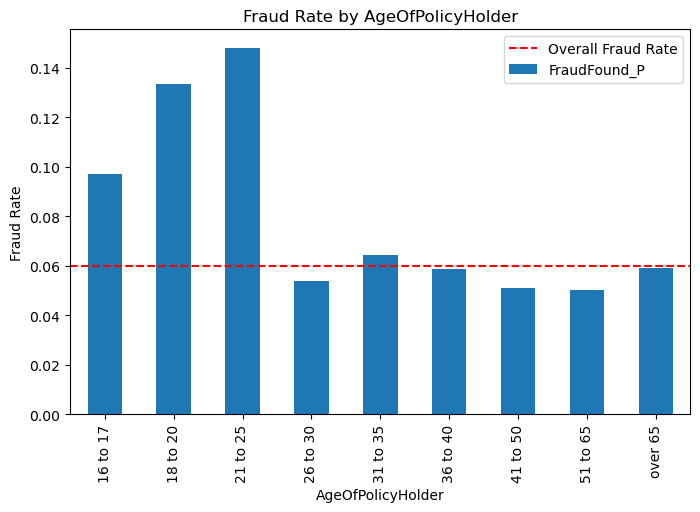

In [21]:
policy_holder_order = ["16 to 17","18 to 20","21 to 25",
                       "26 to 30","31 to 35","36 to 40",
                       "41 to 50","51 to 65","over 65"]

plot_fraud_rate(df_eda, "AgeOfPolicyHolder",
                order=policy_holder_order)

Younger policy holders, particularly those between 16 and 25 years old, exhibit higher fraud rates compared to older age groups.

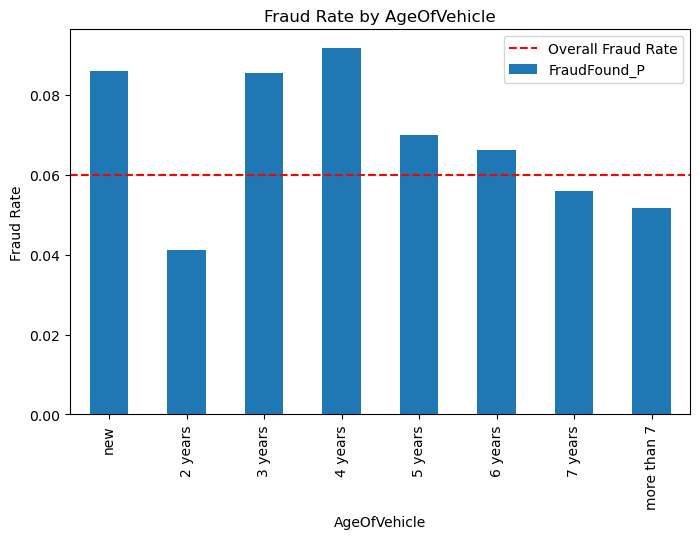

In [22]:
vehicle_age_order = ["new", "2 years", "3 years", "4 years",
                     "5 years", "6 years", "7 years",
                     "more than 7"]

plot_fraud_rate(df_eda, "AgeOfVehicle",
                order=vehicle_age_order)

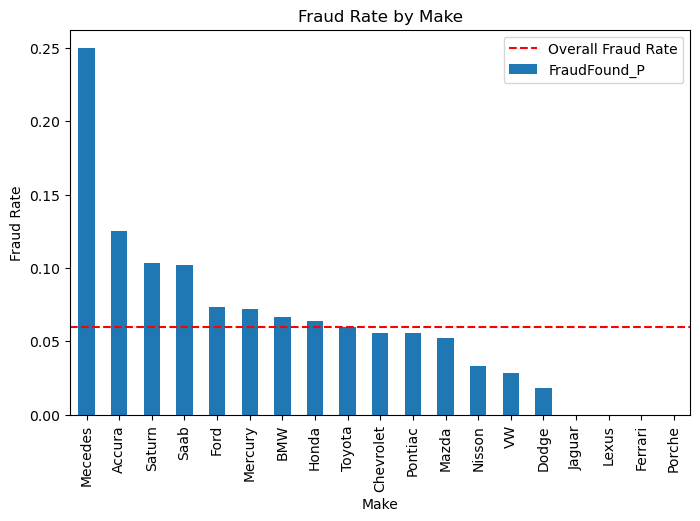

In [23]:
plot_fraud_rate(df_eda, "Make", sort=True)

In [24]:
# Vehicle Brand Frequency Check

df_eda["Make"].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2800
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

Mercedes and Acura exhibit comparatively higher observed fraud rates; however, these categories contain relatively few observations, which may result in unstable rate estimates.

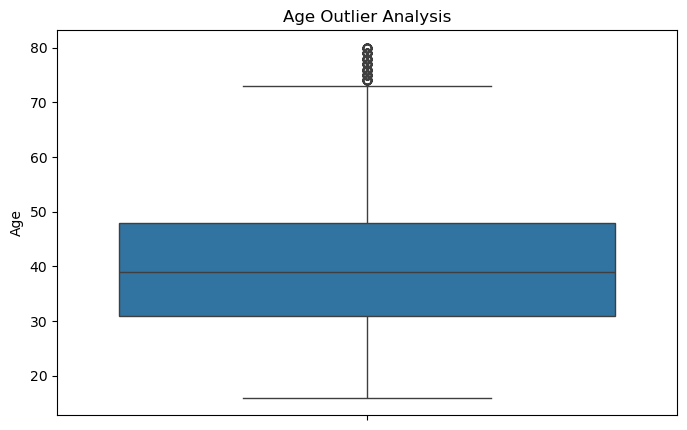

In [25]:
# Age Outlier Check

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_eda, y="Age")

plt.title("Age Outlier Analysis")
plt.ylabel("Age")

plt.show()

The age distribution contains several higher-age observations; however, these values remain within plausible ranges and were retained for further analysis.

### EDA Summary

The exploratory analysis suggests that fraud patterns are more strongly associated with categorical and contextual claim-related features than with numerical variables. Higher fraud rates were observed among younger policy holders, claims without police reports or witnesses, utility vehicles, and cases where the policy holder was at fault. Numerical variables showed weak linear relationships overall, indicating that fraud detection in this dataset may rely more heavily on behavioral and categorical patterns than on standalone numerical features.

## Data Preparation & Preprocessing

In [26]:
# Feature and Target Split

df_pp = df.copy()

X = df_pp.drop("FraudFound_P", axis=1)
y = df_pp["FraudFound_P"]

In [27]:
# Numerical and Categorical Feature Selection

num_cols = []
cat_cols = []

for col in X.columns:
    
    if pd.api.types.is_numeric_dtype(X[col]):
        num_cols.append(col)
        
    else:
        cat_cols.append(col)

In [28]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

## Modeling – Logistic Regression

In [30]:
# Logistic Regression Pipeline

pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)

y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

### Evaluation

In [31]:
# Logistic Regression Performance

f1_lr = f1_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"F1-Score: {f1_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")

F1-Score: 0.2276
Precision: 0.1322
Recall: 0.8162
ROC-AUC: 0.8071


### Threshold Optimization

In [32]:
# Logistic Regression Threshold Evaluation

thresholds = [0.7, 0.6, 0.5, 0.3, 0.2, 0.1]

results_lr = []

for threshold in thresholds:

    y_pred_thresh_lr = (y_proba_lr >= threshold).astype(int)

    precision_lr = precision_score(y_test, y_pred_thresh_lr)

    recall_lr = recall_score(y_test, y_pred_thresh_lr)

    f1_lr = f1_score(y_test, y_pred_thresh_lr)

    results_lr.append({
        "threshold": threshold,
        "precision": precision_lr,
        "recall": recall_lr,
        "f1_score": f1_lr
    })

    print(f"Threshold: {threshold}")

    print(f"Precision: {precision_lr:.4f}")

    print(f"Recall: {recall_lr:.4f}")

    print(f"F1-Score: {f1_lr:.4f}")

    print("-" * 40)

Threshold: 0.7
Precision: 0.1635
Recall: 0.5135
F1-Score: 0.2480
----------------------------------------
Threshold: 0.6
Precision: 0.1462
Recall: 0.7135
F1-Score: 0.2426
----------------------------------------
Threshold: 0.5
Precision: 0.1322
Recall: 0.8162
F1-Score: 0.2276
----------------------------------------
Threshold: 0.3
Precision: 0.1301
Recall: 0.9568
F1-Score: 0.2291
----------------------------------------
Threshold: 0.2
Precision: 0.1259
Recall: 0.9676
F1-Score: 0.2228
----------------------------------------
Threshold: 0.1
Precision: 0.1041
Recall: 0.9784
F1-Score: 0.1882
----------------------------------------


### Threshold Selection

Threshold tuning highlights the trade-off between precision and recall. While a threshold of 0.7 achieves the highest F1-score, it substantially reduces recall and increases the risk of missing fraudulent cases.

Given the objective of fraud detection, where identifying fraudulent claims is prioritized, a threshold of 0.6 was selected to maintain strong recall while slightly improving precision compared to the default threshold.

### Hyperparameter Optimization

In [33]:
# Hyperparameter Search Space

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

In [34]:
# Logistic Regression Hyperparameter Optimization

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['WeekOfMonth',
                                                                          'WeekOfMonthClaimed',
                                                                          'Age',
                                                                          'RepNumber',
                                                                          'Deductible',
                                                                          'DriverRating',
                                                                          'Year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Month',
                                                                          'DayOfWeek',
                                                                          'Make',
                                                                          'AccidentArea',
                                                                          'DayOfWeekClaimed',
                                                                          'MonthClaimed',
                                                                          'Sex',
                                                                          'MaritalStatus...
                                                                          'AgeOfPolicyHolder',
                                                                          'PoliceReportFiled',
                                                                          'WitnessPresent',
                                                                          'AgentType',
                                                                          'NumberOfSuppliments',
                                                                          'AddressChange_Claim',
                                                                          'NumberOfCars',
                                                                          'BasePolicy'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [35]:
# Best Hyperparameters

print("Best Parameters:", grid_search_lr.best_params_)

print("Best F1-Score:", grid_search_lr.best_score_)

Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best F1-Score: 0.22807607978712136


In [36]:
# Best Optimized Logistic Regression Model

best_lr = grid_search_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test)

y_proba_best_lr = best_lr.predict_proba(X_test)[:, 1]

In [37]:
# Optimized Logistic Regression Performance

f1_best_lr = f1_score(y_test, y_pred_best_lr)

precision_best_lr = precision_score(y_test, y_pred_best_lr)

recall_best_lr = recall_score(y_test, y_pred_best_lr)

roc_auc_best_lr = roc_auc_score(y_test, y_proba_best_lr)

print(f"F1-Score: {f1_best_lr:.4f}")

print(f"Precision: {precision_best_lr:.4f}")

print(f"Recall: {recall_best_lr:.4f}")

print(f"ROC-AUC: {roc_auc_best_lr:.4f}")


F1-Score: 0.2276
Precision: 0.1322
Recall: 0.8162
ROC-AUC: 0.8071


### Optimization Summary


Hyperparameter optimization produced results similar to the baseline Logistic Regression model, suggesting that model performance may be limited more by the underlying structure of the dataset than by the selected hyperparameters. While the model achieved strong recall and reasonable ROC-AUC, precision and overall F1-score remained relatively low due to the severe class imbalance and complexity of fraud patterns.

## Modeling – Random Forest


In [38]:
# Random Forest Pipeline

pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

### Evaluation


In [39]:
# Random Forest Performance

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Precision: {precision_rf:.4f}")

print(f"Recall: {recall_rf:.4f}")

print(f"F1-Score: {f1_rf:.4f}")

print(f"ROC-AUC: {roc_auc_rf:.4f}")

Precision: 0.6667
Recall: 0.0108
F1-Score: 0.0213
ROC-AUC: 0.8161


### Evaluation Summary


The initial Random Forest model achieved extremely high precision but very low recall, indicating that the model is highly conservative and identifies only a small portion of fraudulent cases.

However, the strong ROC-AUC score suggests that the model maintains good class-separation capability at the probability level. This indicates that the limitation is likely related to the default classification threshold rather than the model’s overall predictive capacity.

To improve fraud detection performance, threshold tuning was performed to achieve a better balance between precision and recall.

### Threshold Optimization

In [40]:
# Random Forest Threshold Evaluation

results_rf = []

for threshold in thresholds:

    y_pred_thresh_rf = (y_proba_rf >= threshold).astype(int)

    precision_rf = precision_score(y_test, y_pred_thresh_rf)

    recall_rf = recall_score(y_test, y_pred_thresh_rf)

    f1_rf = f1_score(y_test, y_pred_thresh_rf)

    results_rf.append({
        "threshold": threshold,
        "precision": precision_rf,
        "recall": recall_rf,
        "f1_score": f1_rf
    })

    print(f"Threshold: {threshold}")

    print(f"Precision: {precision_rf:.4f}")

    print(f"Recall: {recall_rf:.4f}")

    print(f"F1-Score: {f1_rf:.4f}")

    print("-" * 40)

Threshold: 0.7
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
----------------------------------------
Threshold: 0.6
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
----------------------------------------
Threshold: 0.5
Precision: 0.6667
Recall: 0.0108
F1-Score: 0.0213
----------------------------------------
Threshold: 0.3
Precision: 0.2340
Recall: 0.1189
F1-Score: 0.1577
----------------------------------------
Threshold: 0.2
Precision: 0.1713
Recall: 0.4324
F1-Score: 0.2454
----------------------------------------
Threshold: 0.1
Precision: 0.1363
Recall: 0.8649
F1-Score: 0.2355
----------------------------------------


c:\Users\Yalda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yalda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Threshold Selection

At higher thresholds, the Random Forest model achieves extremely high precision but fails to detect most fraudulent cases, resulting in very low recall.

Lowering the classification threshold substantially improves recall and overall F1-score, indicating that the model assigns relatively conservative fraud probabilities by default.

A threshold of 0.1 was selected as it provides the best balance between fraud detection capability and overall classification performance for this model.

### Hyperparameter Optimization

In [41]:
# Random Forest Hyperparameter Search Space

param_grid_rf = {
    "model__n_estimators": [100],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5]
}

In [42]:
# Random Forest Hyperparameter Optimization

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['WeekOfMonth',
                                                                          'WeekOfMonthClaimed',
                                                                          'Age',
                                                                          'RepNumber',
                                                                          'Deductible',
                                                                          'DriverRating',
                                                                          'Year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Month',
                                                                          'DayOfWeek',
                                                                          'Make',
                                                                          'AccidentArea',
                                                                          'DayOfWeekClaimed',
                                                                          'MonthClaimed',
                                                                          'Sex',
                                                                          'MaritalStatus...
                                                                          'AgeOfPolicyHolder',
                                                                          'PoliceReportFiled',
                                                                          'WitnessPresent',
                                                                          'AgentType',
                                                                          'NumberOfSuppliments',
                                                                          'AddressChange_Claim',
                                                                          'NumberOfCars',
                                                                          'BasePolicy'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100]},
             scoring='f1')

In [43]:
# Best Random Forest Hyperparameters

print("Best Parameters:", grid_search_rf.best_params_)

print("Best F1-Score:", grid_search_rf.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best F1-Score: 0.21788343050831177


In [44]:
# Best Optimized Random Forest Model

best_rf = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [45]:
# Optimized Random Forest Performance

precision_best_rf = precision_score(y_test, y_pred_best_rf)

recall_best_rf = recall_score(y_test, y_pred_best_rf)

f1_best_rf = f1_score(y_test, y_pred_best_rf)

roc_auc_best_rf = roc_auc_score(y_test, y_proba_best_rf)

print(f"Precision: {precision_best_rf:.4f}")

print(f"Recall: {recall_best_rf:.4f}")

print(f"F1-Score: {f1_best_rf:.4f}")

print(f"ROC-AUC: {roc_auc_best_rf:.4f}")

Precision: 0.1892
Recall: 0.3784
F1-Score: 0.2523
ROC-AUC: 0.8182


### Optimization Summary

Hyperparameter optimization substantially improved the Random Forest model’s balance between precision and recall. Compared to the baseline model, recall and overall F1-score increased significantly, while ROC-AUC remained relatively stable.

These results suggest that the baseline Random Forest model was overly conservative in detecting fraudulent cases and that tuning the model parameters improved its ability to identify fraud patterns more effectively.

## Modeling – Gradient Boosting

In [46]:
# Gradient Boosting Pipeline

pipeline_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

pipeline_gb.fit(X_train, y_train)

y_pred_gb = pipeline_gb.predict(X_test)

y_proba_gb = pipeline_gb.predict_proba(X_test)[:, 1]

### Evaluation

In [47]:
# Gradient Boosting Performance

precision_gb = precision_score(y_test, y_pred_gb)

recall_gb = recall_score(y_test, y_pred_gb)

f1_gb = f1_score(y_test, y_pred_gb)

roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

print(f"Precision: {precision_gb:.4f}")

print(f"Recall: {recall_gb:.4f}")

print(f"F1-Score: {f1_gb:.4f}")

print(f"ROC-AUC: {roc_auc_gb:.4f}")

Precision: 0.3750
Recall: 0.0324
F1-Score: 0.0597
ROC-AUC: 0.8304


### Evaluation Summary

The Gradient Boosting model achieved the highest ROC-AUC score among the evaluated models, indicating strong class-separation capability. However, recall remained very low at the default classification threshold, meaning that the model failed to identify most fraudulent cases.

These results suggest that the model generates informative probability estimates but applies overly conservative fraud classifications under the default threshold setting.

### Threshold Optimization

In [48]:
# Gradient Boosting Threshold Evaluation

results_gb = []

for threshold in thresholds:

    y_pred_thresh_gb = (y_proba_gb >= threshold).astype(int)

    precision_gb = precision_score(y_test, y_pred_thresh_gb)

    recall_gb = recall_score(y_test, y_pred_thresh_gb)

    f1_gb = f1_score(y_test, y_pred_thresh_gb)

    results_gb.append({
        "threshold": threshold,
        "precision": precision_gb,
        "recall": recall_gb,
        "f1_score": f1_gb
    })

    print(f"Threshold: {threshold}")

    print(f"Precision: {precision_gb:.4f}")

    print(f"Recall: {recall_gb:.4f}")

    print(f"F1-Score: {f1_gb:.4f}")

    print("-" * 40)

Threshold: 0.7
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
----------------------------------------
Threshold: 0.6
Precision: 0.5000
Recall: 0.0054
F1-Score: 0.0107
----------------------------------------
Threshold: 0.5
Precision: 0.3750
Recall: 0.0324
F1-Score: 0.0597
----------------------------------------
Threshold: 0.3
Precision: 0.2080
Recall: 0.3946
F1-Score: 0.2724
----------------------------------------
Threshold: 0.2
Precision: 0.1484
Recall: 0.7622
F1-Score: 0.2485
----------------------------------------
Threshold: 0.1
Precision: 0.1293
Recall: 0.9568
F1-Score: 0.2278
----------------------------------------


### Threshold Selection

Threshold tuning substantially improved the Gradient Boosting model’s fraud detection capability. While higher thresholds produced extremely conservative predictions and very low recall, lowering the threshold significantly increased the model’s ability to identify fraudulent cases.

A threshold of 0.3 achieved the best overall F1-score while maintaining a more balanced trade-off between precision and recall. Combined with the highest ROC-AUC score among the evaluated models, these results suggest that Gradient Boosting provides the strongest overall predictive performance in this project so far.

### Hyperparameter Optimization

In [49]:
# Optuna Objective Function for Gradient Boosting

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0)
    }

    pipeline_optuna_gb = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(
            random_state=42,
            **params
        ))
    ])

    scores = cross_val_score(
        pipeline_optuna_gb,
        X_train,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()

In [50]:
# Optuna Study

study_gb = optuna.create_study(direction="maximize")

study_gb.optimize(objective, n_trials=20)

[I 2026-05-17 16:54:37,075] A new study created in memory with name: no-name-2bb985a0-19be-466a-bbb5-11e23650a02a
[I 2026-05-17 16:55:09,820] Trial 0 finished with value: 0.09263161319419959 and parameters: {'n_estimators': 155, 'learning_rate': 0.19662459249708666, 'max_depth': 4, 'subsample': 0.8612167083561036}. Best is trial 0 with value: 0.09263161319419959.
[I 2026-05-17 16:55:53,065] Trial 1 finished with value: 0.12724312368156962 and parameters: {'n_estimators': 147, 'learning_rate': 0.2864889136038795, 'max_depth': 5, 'subsample': 0.8507044406511438}. Best is trial 1 with value: 0.12724312368156962.
[I 2026-05-17 16:56:10,780] Trial 2 finished with value: 0.025995809637832986 and parameters: {'n_estimators': 193, 'learning_rate': 0.2410918443762722, 'max_depth': 2, 'subsample': 0.932278058119783}. Best is trial 1 with value: 0.12724312368156962.
[I 2026-05-17 16:56:39,554] Trial 3 finished with value: 0.06626128725224759 and parameters: {'n_estimators': 215, 'learning_rate': 

In [51]:
# Best Optuna Parameters

print("Best Parameters:", study_gb.best_params)

print("Best F1-Score:", study_gb.best_value)

Best Parameters: {'n_estimators': 106, 'learning_rate': 0.0357647188621618, 'max_depth': 3, 'subsample': 0.6479563035876604}
Best F1-Score: 0.23218787108062108


In [52]:
# Optimized Gradient Boosting Model

best_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        random_state=42,
        **study_gb.best_params
    ))
])

best_gb.fit(X_train, y_train)

y_pred_best_gb = best_gb.predict(X_test)

y_proba_best_gb = best_gb.predict_proba(X_test)[:, 1]

### Evaluation

In [53]:
# Optimized Gradient Boosting Performance

precision_best_gb = precision_score(y_test, y_pred_best_gb)

recall_best_gb = recall_score(y_test, y_pred_best_gb)

f1_best_gb = f1_score(y_test, y_pred_best_gb)

roc_auc_best_gb = roc_auc_score(y_test, y_proba_best_gb)

print(f"Precision: {precision_best_gb:.4f}")

print(f"Recall: {recall_best_gb:.4f}")

print(f"F1-Score: {f1_best_gb:.4f}")

print(f"ROC-AUC: {roc_auc_best_gb:.4f}")

Precision: 0.1886
Recall: 0.3946
F1-Score: 0.2552
ROC-AUC: 0.8265


### Optimization Summary

Optuna-based hyperparameter optimization improved the Gradient Boosting model across all major evaluation metrics. Compared to the baseline model, the optimized version achieved higher recall, F1-score, and ROC-AUC, indicating improved fraud detection capability and stronger class-separation performance.

The results suggest that Gradient Boosting benefits substantially from intelligent hyperparameter tuning, particularly through lower learning rates and deeper trees that better capture complex fraud patterns within the dataset.

## Model Comparison

In [54]:
# Model Performance Comparison

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Precision": [
        precision_best_lr,
        precision_best_rf,
        precision_best_gb
    ],
    
    "Recall": [
        recall_best_lr,
        recall_best_rf,
        recall_best_gb
    ],
    
    "F1-Score": [
        f1_best_lr,
        f1_best_rf,
        f1_best_gb
    ],
    
    "ROC-AUC": [
        roc_auc_best_lr,
        roc_auc_best_rf,
        roc_auc_best_gb
    ]
})

comparison_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.132224,0.816216,0.227581,0.807111
1,Random Forest,0.189189,0.378378,0.252252,0.818172
2,Gradient Boosting,0.188630,0.394595,0.255245,0.826473


## Final Conclusion

This project explored multiple machine learning approaches for insurance fraud detection, including Logistic Regression, Random Forest, and Gradient Boosting models combined with preprocessing pipelines, imbalance handling using SMOTE, threshold tuning, and hyperparameter optimization.

Among the evaluated models, the optimized Gradient Boosting model achieved the strongest overall performance, producing the highest F1-score and ROC-AUC while maintaining a more balanced trade-off between precision and recall. The results demonstrate that ensemble boosting methods are more effective at capturing complex fraud patterns compared to simpler linear approaches.

Despite these improvements, fraud detection remained a challenging classification problem due to severe class imbalance and overlapping class characteristics. The project highlights the importance of combining model optimization with threshold tuning to improve fraud detection capability in real-world business settings.